# V5.2 — Semantic backbone + Anchor–Challenger confirmation

Этот ноутбук проверяет вариант, где `Semantic active v3` остаётся основным Pair Generator, а anchor–challenger используется только как короткий confirmation/refinement-блок после `ready_to_finalize`.

Идея: не заменять сильный semantic search, а добавить 1–2 безопасных уточняющих вопроса, чтобы подтвердить текущий профиль и при необходимости сделать маленькую zone-aware корректировку.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from personalization.plotting import use_article_style
use_article_style()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from personalization.batch_eval import win_rates_vs_baseline
from personalization.safe_anchor_challenger import V5_STRATEGY_NAME
from personalization.safe_anchor_challenger_v51 import V51_STRATEGY_NAME
from personalization.safe_anchor_challenger_v52 import (
    V52_DISPLAY_NAMES,
    V52_STRATEGY_NAME,
    run_v52_comparison_on_dataset,
    save_v52_outputs,
    source_usage_table_v52,
    summarize_v52_sessions,
)

DATASET_PATH = ROOT / 'outputs' / 'datasets' / 'synthetic_users_v21.csv'
FIG_DIR = ROOT / 'outputs' / 'figures'
TABLE_DIR = ROOT / 'outputs' / 'tables'
METRICS_DIR = ROOT / 'outputs' / 'metrics'

TARGET_MODE_DISPLAY_NAMES = {
    'random8d': 'Random 8D',
    'semantic4d': 'Semantic 4D',
    'semantic6d': 'Semantic 6D',
    'archetype8d': 'Archetype 8D',
}
TARGET_MODE_ORDER = ['random8d', 'semantic4d', 'semantic6d', 'archetype8d']
STRATEGY_ORDER = ['semantic_active_v21', 'candidate_pool_active', V5_STRATEGY_NAME, V51_STRATEGY_NAME, V52_STRATEGY_NAME]


## Загрузка dataset

In [2]:
dataset = pd.read_csv(DATASET_PATH)
SAMPLE_PER_MODE = 50  # поставь None или 0 для полного dataset

if SAMPLE_PER_MODE is None or SAMPLE_PER_MODE <= 0:
    dataset_eval = dataset.copy()
else:
    sampled_parts = []
    for _, group in dataset.groupby('target_mode'):
        sampled_parts.append(group.sample(n=min(SAMPLE_PER_MODE, len(group)), random_state=42))
    dataset_eval = pd.concat(sampled_parts, axis=0).reset_index(drop=True)

dataset_eval['target_mode'].value_counts()

target_mode
archetype8d    50
random8d       50
semantic4d     50
semantic6d     50
Name: count, dtype: int64

## Запуск эксперимента

In [3]:
sessions, steps, curves = run_v52_comparison_on_dataset(
    dataset_eval,
    baseline_strategies=('semantic_active_v21', 'candidate_pool_active'),
    include_v5=True,
    include_v51=True,
    n_steps=25,
    step_scale=0.6,
    lr=0.25,
    clip_value=2.0,
)
summary = summarize_v52_sessions(sessions)
win_rates = win_rates_vs_baseline(sessions, baseline='semantic_active_v21')
source_usage = source_usage_table_v52(steps)

save_v52_outputs(sessions, steps, summary, win_rates, source_usage, METRICS_DIR)
summary

,target_mode,strategy,users,mean_used_steps,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,...,mean_ready_step,ready_rate,mean_confirmation_start_step,mean_confirmation_questions,mean_anchor_selected_rate,mean_pair_distance,mean_audibility_score,mean_acceptability_score,mean_midrange_penalty,mean_applied_lr
3,archetype8d,semantic_active_v21,50,25.00,1.095608,0.356318,0.097223,0.262863,0.563689,58.871640,...,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,archetype8d,safe_anchor_challenger_v51,50,25.00,1.095608,0.415218,0.207245,0.371329,0.586884,57.342985,...,15.14,1.0,NaN,NaN,NaN,0.651206,0.676796,0.985696,0.019024,0.146736
4,archetype8d,semantic_backbone_confirmation_v52,50,16.08,1.095608,0.453654,0.206498,0.376616,0.587690,51.405913,...,14.08,1.0,15.08,2.0,0.66,0.593857,0.667013,0.988920,0.011869,0.141888
0,archetype8d,candidate_pool_active,50,25.00,1.095608,0.464350,0.122402,0.317149,0.627398,43.442265,...,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,archetype8d,safe_anchor_challenger_v5,50,25.00,1.095608,0.607925,0.142412,0.318501,0.631008,22.861836,...,14.08,1.0,NaN,NaN,NaN,0.792928,0.860641,0.980294,0.061211,NaN
5,random8d,candidate_pool_active,50,25.00,2.121827,0.929062,0.426393,0.899346,1.480757,57.128157,...,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
6,random8d,safe_anchor_challenger_v5,50,25.00,2.121827,1.424407,0.486064,1.379056,1.669332,32.449087,...,14.02,1.0,NaN,NaN,NaN,0.789168,0.854368,0.981523,0.057920,NaN
8,random8d,semantic_active_v21,50,25.00,2.121827,1.437136,0.491308,1.408497,1.665587,31.339169,...,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
7,random8d,safe_anchor_challenger_v51,50,25.00,2.121827,1.551229,0.546623,1.538188,1.699127,27.232974,...,15.12,1.0,NaN,NaN,NaN,0.655608,0.702582,0.984998,0.020054,0.147968
9,random8d,semantic_backbone_confirmation_v52,50,16.00,2.121827,1.562376,0.504926,1.542291,1.693985,26.123286,...,14.00,1.0,15.00,2.0,0.63,0.591215,0.712436,0.986122,0.014518,0.141184


## Mean final distance по target modes

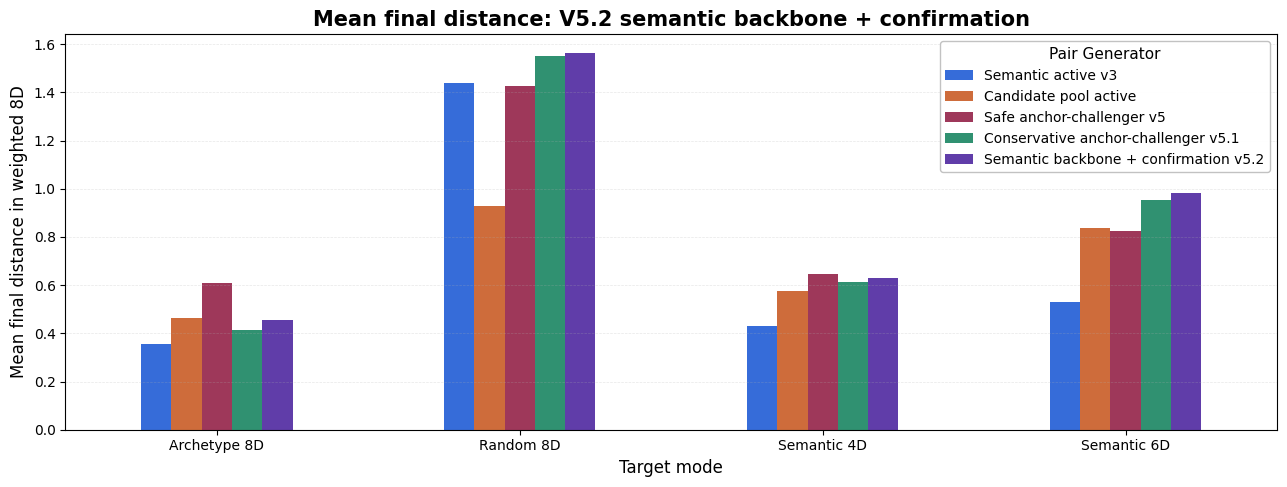

In [4]:
df = summary.copy()
df['target_mode_display'] = df['target_mode'].map(TARGET_MODE_DISPLAY_NAMES).fillna(df['target_mode'])
df['strategy_display'] = df['strategy'].map(V52_DISPLAY_NAMES).fillna(df['strategy'])
df['target_mode'] = pd.Categorical(df['target_mode'], TARGET_MODE_ORDER, ordered=True)
df['strategy'] = pd.Categorical(df['strategy'], STRATEGY_ORDER, ordered=True)
df = df.sort_values(['target_mode', 'strategy'])
pivot = df.pivot(index='target_mode_display', columns='strategy_display', values='mean_final_distance')
cols = [V52_DISPLAY_NAMES[s] for s in STRATEGY_ORDER if V52_DISPLAY_NAMES.get(s) in pivot.columns]
pivot = pivot[cols]

fig, ax = plt.subplots(figsize=(13, 5), facecolor='white')
pivot.plot(kind='bar', ax=ax)
ax.set_title('Mean final distance: V5.2 semantic backbone + confirmation', fontsize=15, fontweight='bold')
ax.set_xlabel('Target mode')
ax.set_ylabel('Mean final distance in weighted 8D')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.legend(title='Pair Generator', frameon=True, facecolor='white', edgecolor='0.75')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Сходимость на Archetype 8D

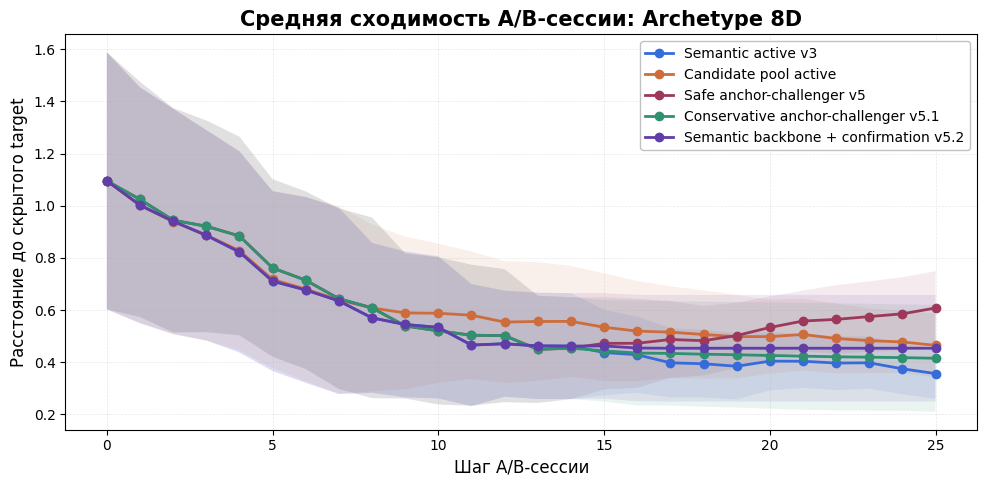

In [5]:
mode = 'archetype8d'
fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')
for strategy in STRATEGY_ORDER:
    arr = curves.get(mode, {}).get(strategy)
    if arr is None or len(arr) == 0:
        continue
    mean = arr.mean(axis=0)
    std = arr.std(axis=0)
    x = np.arange(len(mean))
    ax.plot(x, mean, marker='o', linewidth=2, label=V52_DISPLAY_NAMES.get(strategy, strategy))
    ax.fill_between(x, mean - std, mean + std, alpha=0.10)
ax.set_title('Средняя сходимость A/B-сессии: Archetype 8D', fontsize=15, fontweight='bold')
ax.set_xlabel('Шаг A/B-сессии')
ax.set_ylabel('Расстояние до скрытого target')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(frameon=True, facecolor='white', edgecolor='0.75')
plt.tight_layout()
plt.show()

## V5.2 на Archetype 8D

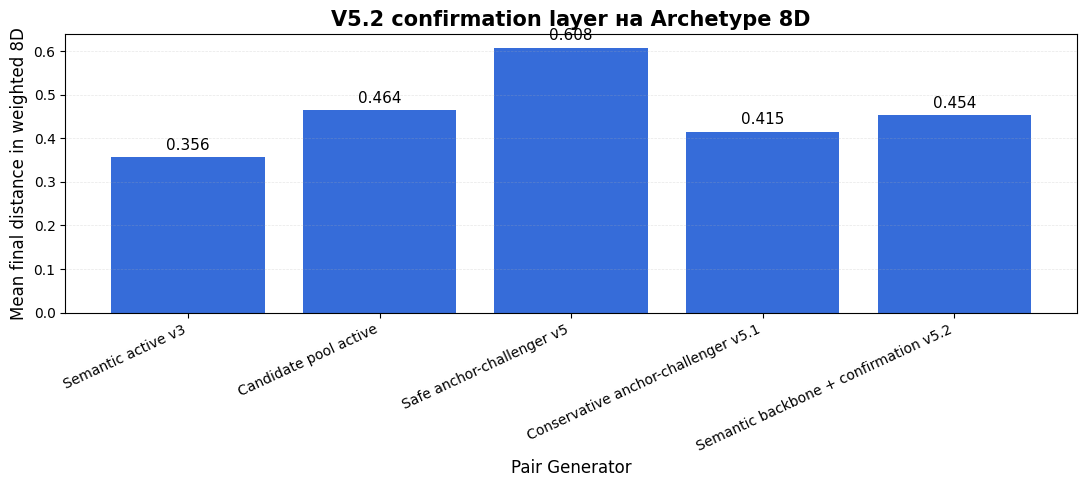

,strategy_display,mean_final_distance,mean_used_steps,mean_ready_step,ready_rate,mean_confirmation_questions
3,Semantic active v3,0.356318,25.00,NaN,0.0,0.0
0,Candidate pool active,0.464350,25.00,NaN,0.0,0.0
1,Safe anchor-challenger v5,0.607925,25.00,14.08,1.0,NaN
2,Conservative anchor-challenger v5.1,0.415218,25.00,15.14,1.0,NaN
4,Semantic backbone + confirmation v5.2,0.453654,16.08,14.08,1.0,2.0


In [6]:
df = summary[(summary['target_mode'] == 'archetype8d') & (summary['strategy'].isin(STRATEGY_ORDER))].copy()
df['strategy'] = pd.Categorical(df['strategy'], STRATEGY_ORDER, ordered=True)
df = df.sort_values('strategy')
df['strategy_display'] = df['strategy'].map(V52_DISPLAY_NAMES).fillna(df['strategy'].astype(str))

fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
bars = ax.bar(df['strategy_display'], df['mean_final_distance'])
ax.set_title('V5.2 confirmation layer на Archetype 8D', fontsize=15, fontweight='bold')
ax.set_xlabel('Pair Generator')
ax.set_ylabel('Mean final distance in weighted 8D')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.bar_label(bars, fmt='%.3f', padding=3)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

df[['strategy_display', 'mean_final_distance', 'mean_used_steps', 'mean_ready_step', 'ready_rate', 'mean_confirmation_questions']]

## Диагностика фаз и качества пар

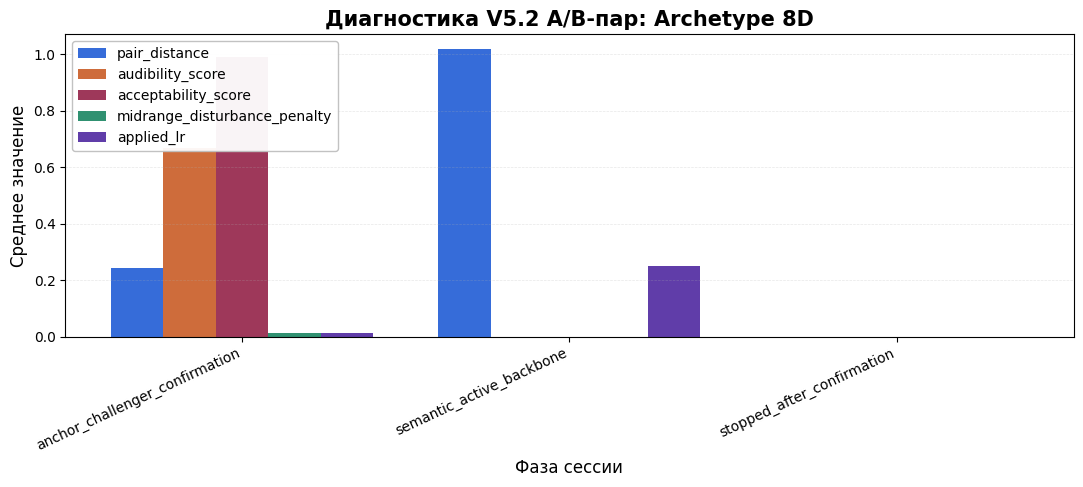

,phase,pair_distance,audibility_score,acceptability_score,midrange_disturbance_penalty,applied_lr
0,anchor_challenger_confirmation,0.242411,0.667013,0.98892,0.011869,0.0136
1,semantic_active_backbone,1.020000,NaN,NaN,NaN,0.2500
2,stopped_after_confirmation,0.000000,NaN,NaN,NaN,0.0000


In [7]:
df_steps = steps[(steps['target_mode'] == 'archetype8d') & (steps['strategy'] == V52_STRATEGY_NAME)].copy()
metrics = ['pair_distance', 'audibility_score', 'acceptability_score', 'midrange_disturbance_penalty', 'applied_lr']
grouped = df_steps.groupby('phase')[metrics].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
x = np.arange(len(grouped))
width = 0.16
for i, metric in enumerate(metrics):
    ax.bar(x + (i - 2) * width, grouped[metric], width=width, label=metric)
ax.set_title('Диагностика V5.2 A/B-пар: Archetype 8D', fontsize=15, fontweight='bold')
ax.set_xlabel('Фаза сессии')
ax.set_ylabel('Среднее значение')
ax.set_xticks(x)
ax.set_xticklabels(grouped['phase'], rotation=25, ha='right')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.legend(frameon=True, facecolor='white', edgecolor='0.75')
plt.tight_layout()
plt.show()

grouped

## Источники A/B-вопросов V5.2

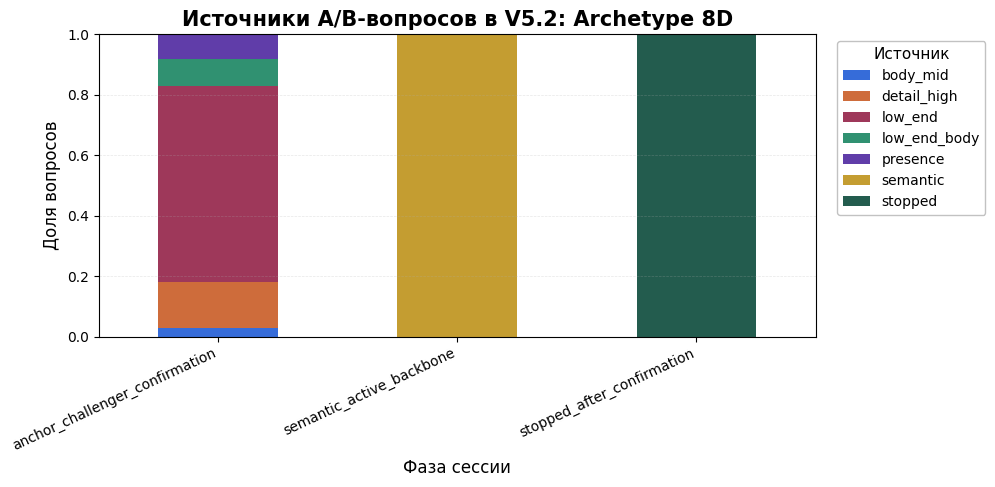

pair_source_group,body_mid,detail_high,low_end,low_end_body,presence,semantic,stopped
phase,,,,,,,
anchor_challenger_confirmation,0.03,0.15,0.65,0.09,0.08,0.0,0.0
semantic_active_backbone,0.00,0.00,0.00,0.00,0.00,1.0,0.0
stopped_after_confirmation,0.00,0.00,0.00,0.00,0.00,0.0,1.0


In [8]:
df_src = source_usage[(source_usage['target_mode'] == 'archetype8d') & (source_usage['strategy'] == V52_STRATEGY_NAME)].copy()
pivot = df_src.pivot_table(index='phase', columns='pair_source_group', values='share', aggfunc='sum').fillna(0.0)
fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')
pivot.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Источники A/B-вопросов в V5.2: Archetype 8D', fontsize=15, fontweight='bold')
ax.set_xlabel('Фаза сессии')
ax.set_ylabel('Доля вопросов')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.legend(title='Источник', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

pivot

## Вывод

`V5.2` проверяет более осторожную гипотезу: оставить `Semantic active v3` основным генератором, а anchor–challenger использовать только как короткий confirmation layer после готовности системы.

Если V5.2 сохраняет final distance близко к `Semantic active v3`, но использует меньше шагов или даёт более понятные confirmation-пары, такой слой можно рассматривать как продуктовую надстройку: система сначала ищет вкус, затем подтверждает текущий профиль и предлагает завершить сессию.

Если V5.2 хуже, это значит, что даже confirmation-block пока требует более аккуратных условий включения или лучше оставить anchor–challenger только как UX-вопросы без влияния на `z_mean`.